# Clustering of COVID-19 Municipality Time Series: RIVM vs ABM Simulation

This notebook presents a reproducible analysis pipeline for comparing municipality-level COVID-19 time series from observed **RIVM** data and simulated **Agent-Based Model (ABM)** outputs. The workflow covers data loading, restructuring, preprocessing, segmentation of epidemic waves, clustering of time-series patterns, and the interpretation of possible **hierarchical diffusion structures**.

### Notebook structure

The notebook is organised into the following sections:

- **Section 0:** Setup and reproducibility  
- **Section 1:** Research aim and analytical plan  
- **Section 2:** Load and inspect the data  
- **Section 3:** Data architecture and restructuring  
- **Section 4:** Preprocessing choices  
- **Section 5:** Time-series segmentation  
- **Section 6:** Clustering design  
- **Section 7:** Clustering results for RIVM  
- **Section 8:** Clustering results for ABM  
- **Section 9:** Comparative analysis: RIVM vs ABM  
- **Section 10:** Sensitivity analysis  
- **Section 11:** Limitations  
- **Section 12:** Conclusions  
- **Section 13:** Export outputs

## Section 0 — Setup and reproducibility

This section defines the computational environment, project paths, helper functions, and reproducibility settings used throughout the analysis.

### 0.1 Imports

The following libraries are used for data handling, visualisation, preprocessing, clustering, and reproducibility. Imports are grouped by purpose to keep the workflow readable.

In [1]:
# Core Python
import os
import random
import warnings
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical / preprocessing tools
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import silhouette_score

# Time-series clustering
# Keep only the ones you will actually use
from tslearn.clustering import KShape
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

# Optional: segmentation / change point detection
# Uncomment if installed and used later
# import ruptures as rpt

# Optional: Self-Organising Map package
# Uncomment depending on your setup
# import somoclu

#warnings.filterwarnings("ignore")

### 0.2 Paths and configuration

To keep the notebook reproducible, all input and output paths are defined in one place. This makes it easier to move the project to another machine or reorganise files later without rewriting code throughout the notebook.

In [2]:
# Project root
PROJECT_ROOT = Path.cwd().parent

# Suggested folder structure
DATA_RAW_DIR = PROJECT_ROOT / "data_raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data_processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
TABLES_DIR = PROJECT_ROOT / "tables"
EXPORT_DIR = PROJECT_ROOT / "exports"

# Create output folders if they do not exist
for folder in [DATA_PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, EXPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# File paths (edit these once your files are ready)
RIVM_FILE = DATA_RAW_DIR / "rivm_data.csv"
ABM_FILE = DATA_RAW_DIR / "OutputBasemodel.csv"

print("Project root:", PROJECT_ROOT)
print("RIVM file path:", RIVM_FILE)
print("ABM file path:", ABM_FILE)

Project root: /home/lorem/Documents/github/space_time_individual
RIVM file path: /home/lorem/Documents/github/space_time_individual/data_raw/rivm_data.csv
ABM file path: /home/lorem/Documents/github/space_time_individual/data_raw/OutputBasemodel.csv


In [3]:
# Plotting defaults
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["figure.dpi"] = 120

### 0.3 Helper functions

The helper functions below are defined once and reused later in the notebook. They support inspection, standardised plotting, export, and simple preprocessing checks. Keeping these functions here improves readability in later sections.

In [4]:
def inspect_dataframe(df: pd.DataFrame, name: str = "DataFrame", n: int = 5) -> None:
    """
    Print a compact overview of a DataFrame.
    """
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(f"Shape: {df.shape}")
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nMissing values:")
    print(df.isna().sum().sort_values(ascending=False).head(10))
    print(f"\nPreview (first {n} rows):")
    display(df.head(n))

In [5]:
def save_figure(fig, filename: str, dpi: int = 300) -> None:
    """
    Save a Matplotlib figure to the figures directory.
    """
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"Figure saved to: {output_path}")

In [6]:
def summarise_time_matrix(df: pd.DataFrame, name: str = "Time-series matrix") -> pd.DataFrame:
    """
    Return a compact summary for a municipality x time matrix.
    Assumes rows are municipalities and columns are time steps.
    """
    summary = pd.DataFrame({
        "n_municipalities": [df.shape[0]],
        "n_time_steps": [df.shape[1]],
        "total_missing": [df.isna().sum().sum()],
        "min_value": [np.nanmin(df.values)],
        "max_value": [np.nanmax(df.values)],
        "mean_value": [np.nanmean(df.values)]
    })
    print(f"\n{name} summary:")
    display(summary)
    return summary

In [7]:
def rolling_smooth_series(series: pd.Series, window: int = 3) -> pd.Series:
    """
    Apply a centred rolling mean to a pandas Series.
    """
    return series.rolling(window=window, center=True, min_periods=1).mean()

In [8]:
def zscore_by_row(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply row-wise z-score standardisation.
    Useful when each row is a municipality time series.
    """
    values = df.values.astype(float)
    means = np.nanmean(values, axis=1, keepdims=True)
    stds = np.nanstd(values, axis=1, keepdims=True)
    stds[stds == 0] = 1.0
    z = (values - means) / stds
    return pd.DataFrame(z, index=df.index, columns=df.columns)

In [9]:
def minmax_by_row(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply row-wise min-max scaling to a municipality x time matrix.
    """
    values = df.values.astype(float)
    row_min = np.nanmin(values, axis=1, keepdims=True)
    row_max = np.nanmax(values, axis=1, keepdims=True)
    denom = row_max - row_min
    denom[denom == 0] = 1.0
    scaled = (values - row_min) / denom
    return pd.DataFrame(scaled, index=df.index, columns=df.columns)

In [10]:
def quick_heatmap(df: pd.DataFrame, title: str = "Heatmap", cmap: str = "viridis"):
    """
    Plot a simple heatmap for a matrix-like DataFrame.
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(df, cmap=cmap, ax=ax, cbar=True)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Municipality")
    plt.tight_layout()
    plt.show()

In [11]:
def print_package_versions():
    import sys
    print("Python version:", sys.version.split()[0])
    print("pandas version:", pd.__version__)
    print("numpy version:", np.__version__)
    print("matplotlib version:", plt.matplotlib.__version__)
    print("seaborn version:", sns.__version__)

print_package_versions()

Python version: 3.13.5
pandas version: 3.0.1
numpy version: 2.4.3
matplotlib version: 3.10.8
seaborn version: 0.13.2


### 0.4 Reproducibility settings

To make the analysis as reproducible as possible, a fixed random seed is defined for Python and NumPy. Any stochastic modelling or clustering procedure later in the notebook should use the same seed where possible.

In [12]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Random seed set to: {RANDOM_SEED}")

Random seed set to: 42


In [13]:
from datetime import datetime

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print("Notebook run timestamp:", RUN_TIMESTAMP)

Notebook run timestamp: 2026-03-09 13:22:47


## Section 1 — Research aim and analytical plan

The purpose of this notebook is to compare **observed COVID-19 municipality time series from RIVM** with **simulated municipality time series generated by an Agent-Based Model (ABM)**. The analysis focuses on identifying recurring temporal patterns in both datasets and evaluating whether these patterns indicate **hierarchical diffusion**, whereby infection spreads from larger urban centres towards smaller and less connected municipalities.

In addition, this notebook investigates how methodological choices influence interpretation. Specifically, it examines whether **preprocessing decisions** such as smoothing, normalisation, and segmentation, as well as the choice of **clustering algorithm**, affect the detectability and interpretability of epidemic patterns.

### Research questions

1. **What temporal patterns can be identified in municipality-level COVID-19 time series?**
2. **To what extent do RIVM and ABM data exhibit similar or different cluster structures?**
3. **Do the resulting temporal and spatial cluster patterns support the interpretation of hierarchical diffusion?**

### Analytical plan

To answer these questions, the notebook proceeds through the following stages:

1. **Data loading and inspection** of the RIVM and ABM datasets.
2. **Restructuring** both datasets into comparable municipality × time matrices.
3. **Preprocessing** through smoothing, transformation, and temporal alignment.
4. **Segmentation and clustering** to identify epidemic phases and temporal groups.
5. **Comparative interpretation** of temporal and spatial cluster structures in relation to hierarchical diffusion.

## Section 2 — Load and inspect the data

Before performing any preprocessing or clustering, it is necessary to understand the structure and characteristics of the available datasets.

Two sources of data are used in this analysis:

- **RIVM COVID-19 data**, which contains reported infection counts for municipalities in the Netherlands.
- **ABM simulation output**, which contains simulated infection counts generated by an Agent-Based Model.

The ABM output includes municipality identifiers, coordinates, and infection counts over time, while the RIVM dataset requires restructuring into a **municipality × time series format** before further analysis.

This section loads both datasets and performs an initial inspection to understand their structure, dimensions, temporal coverage, and potential data quality issues.

### 2.1 Load RIVM data

The RIVM dataset contains reported COVID-19 cases for Dutch municipalities over time. The dataset is loaded and inspected to understand the available variables, temporal coverage, and number of municipalities.

At this stage, the data is inspected in its **raw format**, before any restructuring or preprocessing.

In [41]:
# Load RIVM data
rivm_df = pd.read_csv(RIVM_FILE, sep=";", low_memory=False)

# Define key columns for later use
municipality_col = "Municipality_name"
municipality_code_col = "Municipality_code"
date_col = "Date_of_publication"
cases_col = "Total_reported"

# Convert date column
rivm_df[date_col] = pd.to_datetime(rivm_df[date_col], dayfirst=True, errors="coerce")

# Inspect dataset
inspect_dataframe(rivm_df, "RIVM Raw Dataset")


RIVM Raw Dataset
Shape: (217248, 12)

Columns:
['Version', 'Date_of_report', 'Date_of_publication', 'Municipality_code', 'Municipality_name', 'Province', 'Security_region_code', 'Security_region_name', 'Municipal_health_service', 'ROAZ_region', 'Total_reported', 'Deceased']

Missing values:
Municipality_code           15184
Municipality_name           15184
ROAZ_region                  4088
Security_region_name         1168
Security_region_code         1168
Province                      584
Municipal_health_service      584
Version                         0
Date_of_publication             0
Date_of_report                  0
dtype: int64

Preview (first 5 rows):


,Version,Date_of_report,Date_of_publication,Municipality_code,Municipality_name,Province,Security_region_code,Security_region_name,Municipal_health_service,ROAZ_region,Total_reported,Deceased
0,6,2-9-2022 10:00,2020-02-28,GM0014,Groningen,Groningen,VR01,Groningen,GGD Groningen,Acute Zorgnetwerk Noord Nederland,0,0
1,6,2-9-2022 10:00,2020-02-28,GM0034,Almere,Flevoland,VR25,Flevoland,GGD Flevoland,SpoedZorgNet,0,0
2,6,2-9-2022 10:00,2020-02-28,GM0037,Stadskanaal,Groningen,VR01,Groningen,GGD Groningen,Acute Zorgnetwerk Noord Nederland,0,0
3,6,2-9-2022 10:00,2020-02-28,GM0047,Veendam,Groningen,VR01,Groningen,GGD Groningen,Acute Zorgnetwerk Noord Nederland,0,0
4,6,2-9-2022 10:00,2020-02-28,GM0050,Zeewolde,Flevoland,VR25,Flevoland,GGD Flevoland,SpoedZorgNet,0,0


In [42]:
print("\nDataset dimensions:")
print(rivm_df.shape)

print("\nColumn names:")
print(rivm_df.columns.tolist())

print("\nData types:")
display(rivm_df.dtypes)


Dataset dimensions:
(217248, 12)

Column names:
['Version', 'Date_of_report', 'Date_of_publication', 'Municipality_code', 'Municipality_name', 'Province', 'Security_region_code', 'Security_region_name', 'Municipal_health_service', 'ROAZ_region', 'Total_reported', 'Deceased']

Data types:


Version                              int64
Date_of_report                         str
Date_of_publication         datetime64[us]
Municipality_code                      str
Municipality_name                      str
Province                               str
Security_region_code                   str
Security_region_name                   str
Municipal_health_service               str
ROAZ_region                            str
Total_reported                       int64
Deceased                             int64
dtype: object

### 2.2 Load ABM output

The ABM simulation output contains simulated infection counts at the municipality level. In addition to infection values over time, the output includes municipality names and coordinates.

The model output file contains a small text header before the actual table, so the file must be read with the correct separator and skipped rows before inspection. In addition, the exported file contains an empty trailing column, which is removed immediately after loading.

In [43]:
# Load ABM output
abm_df = pd.read_csv(
    ABM_FILE,
    sep=";",
    skiprows=2,
    low_memory=False
)

# Clean column names and string values
abm_df.columns = abm_df.columns.str.strip()
abm_df = abm_df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

# Drop empty trailing columns introduced by the export format
abm_df = abm_df.dropna(axis=1, how="all")

# Create a cleaned municipality name column for later comparison
if "name" in abm_df.columns:
    abm_df["name_clean"] = (
        abm_df["name"]
        .str.replace("0", " ", regex=False)
        .str.strip()
    )

# Inspect dataset
inspect_dataframe(abm_df, "ABM Raw Dataset")


ABM Raw Dataset
Shape: (31284, 10)

Columns:
['ticks', 'name', 'xcor', 'ycor', 'totalpopulation', 'totalsusceptible', 'totalexposed', 'totalinfected', 'totalrecovered', 'name_clean']

Missing values:
ticks               0
name                0
xcor                0
ycor                0
totalpopulation     0
totalsusceptible    0
totalexposed        0
totalinfected       0
totalrecovered      0
name_clean          0
dtype: int64

Preview (first 5 rows):


,ticks,name,xcor,ycor,totalpopulation,totalsusceptible,totalexposed,totalinfected,totalrecovered,name_clean
0,0,Wassenaar,-6.480864,-2.417199,25653.42,25653.42,0.0,0.0,0.0,Wassenaar
1,0,Molenwaard,-2.967947,-4.704459,29187.10,29187.10,0.0,0.0,0.0,Molenwaard
2,0,Hof0van0Twente,8.845898,1.653454,35211.48,35211.48,0.0,0.0,0.0,Hof van Twente
3,0,Loppersum,7.180253,14.423434,10290.95,10290.95,0.0,0.0,0.0,Loppersum
4,0,Venlo,7.743379,-8.595810,100148.99,100148.99,0.0,0.0,0.0,Venlo


In [44]:
print("\nDataset dimensions:")
print(abm_df.shape)

print("\nColumn names:")
print(abm_df.columns.tolist())

print("\nData types:")
display(abm_df.dtypes)


Dataset dimensions:
(31284, 10)

Column names:
['ticks', 'name', 'xcor', 'ycor', 'totalpopulation', 'totalsusceptible', 'totalexposed', 'totalinfected', 'totalrecovered', 'name_clean']

Data types:


ticks                 int64
name                    str
xcor                float64
ycor                float64
totalpopulation     float64
totalsusceptible    float64
totalexposed        float64
totalinfected       float64
totalrecovered      float64
name_clean              str
dtype: object

### 2.3 Initial inspection

To better understand the datasets, several descriptive statistics and structural characteristics are examined:

- number of municipalities
- number of time steps
- temporal coverage
- observation frequency

These metrics help determine how the datasets must be restructured before clustering analysis.

In [45]:
# RIVM municipality count
n_municipalities_rivm = rivm_df[municipality_col].nunique(dropna=True)

print("Number of municipalities (RIVM):", n_municipalities_rivm)

Number of municipalities (RIVM): 344


In [46]:
print("Earliest observation (RIVM):", rivm_df[date_col].min())
print("Latest observation (RIVM):", rivm_df[date_col].max())

Earliest observation (RIVM): 2020-02-28 00:00:00
Latest observation (RIVM): 2021-10-03 00:00:00


In [47]:
n_time_steps_rivm = rivm_df[date_col].nunique()

print("Number of time steps (RIVM):", n_time_steps_rivm)

Number of time steps (RIVM): 584


In [48]:
# Observation frequency for RIVM
dates = rivm_df[date_col].dropna().sort_values().unique()
date_diffs = pd.Series(dates).diff()

print("Unique time intervals in RIVM data:")
print(date_diffs.dropna().unique())

Unique time intervals in RIVM data:
<TimedeltaArray>
['1 days']
Length: 1, dtype: timedelta64[us]


In [49]:
# ABM municipality and time-step inspection
abm_municipality_col = "name"
abm_time_col = "ticks"

if abm_municipality_col in abm_df.columns:
    print("Number of municipalities (ABM):", abm_df[abm_municipality_col].nunique())

if abm_time_col in abm_df.columns:
    print("Number of time steps (ABM):", abm_df[abm_time_col].nunique())
    print("Minimum tick:", abm_df[abm_time_col].min())
    print("Maximum tick:", abm_df[abm_time_col].max())

Number of municipalities (ABM): 396
Number of time steps (ABM): 79
Minimum tick: 0
Maximum tick: 546


According to the model instructions, the ABM output reports infection counts at **7-day intervals** rather than daily intervals. Therefore, the simulation output must later be aligned with the daily RIVM observations, for example by aggregating or resampling to a comparable weekly temporal unit.

### 2.4 Missing values and formatting issues

Before restructuring the data, it is important to identify potential data quality issues such as:

- missing values
- inconsistent municipality names
- duplicate records
- irregular timestamps

These issues may influence preprocessing decisions later in the workflow.

In [50]:
print("Missing values in RIVM dataset:")
display(rivm_df.isna().sum().sort_values(ascending=False))

Missing values in RIVM dataset:


Municipality_code           15184
Municipality_name           15184
ROAZ_region                  4088
Security_region_name         1168
Security_region_code         1168
Province                      584
Municipal_health_service      584
Version                         0
Date_of_publication             0
Date_of_report                  0
Total_reported                  0
Deceased                        0
dtype: int64

In [51]:
print("Missing values in ABM dataset:")
display(abm_df.isna().sum().sort_values(ascending=False))

Missing values in ABM dataset:


ticks               0
name                0
xcor                0
ycor                0
totalpopulation     0
totalsusceptible    0
totalexposed        0
totalinfected       0
totalrecovered      0
name_clean          0
dtype: int64

In [52]:
# Duplicate municipality-date records in RIVM
duplicates_rivm = rivm_df.duplicated(
    subset=[date_col, municipality_col]
).sum()

print("Duplicate municipality-date records in RIVM:", duplicates_rivm)

Duplicate municipality-date records in RIVM: 15768


In [53]:
# Inspect duplicate municipality-date records in RIVM
rivm_dup_examples = rivm_df[
    rivm_df.duplicated(subset=[date_col, municipality_col], keep=False)
].sort_values([date_col, municipality_col])

display(rivm_dup_examples.head(20))

,Version,Date_of_report,Date_of_publication,Municipality_code,Municipality_name,Province,Security_region_code,Security_region_name,Municipal_health_service,ROAZ_region,Total_reported,Deceased
106,6,2-9-2022 10:00,2020-02-28,GM0363,Amsterdam,Noord-Holland,VR13,Amsterdam-Amstelland,GGD Amsterdam,Netwerk Acute Zorg Noordwest,0,0
107,6,2-9-2022 10:00,2020-02-28,GM0363,Amsterdam,Noord-Holland,VR13,Amsterdam-Amstelland,GGD Amsterdam,SpoedZorgNet,0,0
131,6,2-9-2022 10:00,2020-02-28,GM0439,Purmerend,Noord-Holland,VR11,Zaanstreek-Waterland,GGD Zaanstreek/Waterland,Netwerk Acute Zorg Noordwest,0,0
132,6,2-9-2022 10:00,2020-02-28,GM0439,Purmerend,Noord-Holland,VR11,Zaanstreek-Waterland,GGD Zaanstreek/Waterland,SpoedZorgNet,0,0
346,6,2-9-2022 10:00,2020-02-28,NaN,NaN,Groningen,VR01,Groningen,GGD Groningen,Acute Zorgnetwerk Noord Nederland,0,0
347,6,2-9-2022 10:00,2020-02-28,NaN,NaN,Drenthe,VR03,Drenthe,GGD Drenthe,NaN,0,0
348,6,2-9-2022 10:00,2020-02-28,NaN,NaN,Overijssel,VR04,IJsselland,GGD IJsselland,Netwerk Acute Zorg regio Zwolle,0,0
349,6,2-9-2022 10:00,2020-02-28,NaN,NaN,Overijssel,VR05,Twente,GGD Twente,Acute Zorg Euregio,0,0
350,6,2-9-2022 10:00,2020-02-28,NaN,NaN,Gelderland,VR06,Noord- en Oost-Gelderland,GGD Noord- en Oost-Gelderland,NaN,0,0
351,6,2-9-2022 10:00,2020-02-28,NaN,NaN,Gelderland,VR07,Gelderland-Midden,Veiligheids- en Gezondheidsregio Gelderland-Mi...,NaN,0,0


The duplicate municipality-date combinations in the RIVM dataset appear to be related to records with missing municipality identifiers or reporting peculiarities in the raw data export. These will be handled explicitly during restructuring and cleaning in the next section.

In [55]:
# Duplicate municipality-tick records in ABM
if {"name", "ticks"}.issubset(abm_df.columns):
    duplicates_abm = abm_df.duplicated(subset=["name", "ticks"]).sum()
    print("Duplicate municipality-tick records in ABM:", duplicates_abm)

Duplicate municipality-tick records in ABM: 0


In [56]:
print("Unique municipalities in RIVM:", rivm_df[municipality_col].nunique(dropna=True))

print("\nExample municipality names from RIVM:")
display(pd.Series(rivm_df[municipality_col].dropna().unique()[:20], name="Municipality_name"))

Unique municipalities in RIVM: 344

Example municipality names from RIVM:


0            Groningen
1               Almere
2          Stadskanaal
3              Veendam
4             Zeewolde
5        Achtkarspelen
6              Ameland
7            Harlingen
8           Heerenveen
9           Leeuwarden
10    Ooststellingwerf
11          Opsterland
12     Schiermonnikoog
13      Smallingerland
14        Terschelling
15            Vlieland
16    Weststellingwerf
17               Assen
18           Coevorden
19               Emmen
Name: Municipality_name, dtype: str

In [57]:
if "name" in abm_df.columns:
    print("Unique municipalities in ABM:", abm_df["name"].nunique())

    print("\nExample raw municipality names from ABM:")
    display(pd.Series(abm_df["name"].dropna().unique()[:20], name="name"))

Unique municipalities in ABM: 396

Example raw municipality names from ABM:


0             Wassenaar 
1            Molenwaard 
2        Hof0van0Twente 
3             Loppersum 
4                 Venlo 
5             Heemstede 
6             Drimmelen 
7                Eemnes 
8        Waddeneilanden 
9                Leiden 
10          Onderbanken 
11            het0Bildt 
12     Ooststellingwerf 
13                Delft 
14        Echt0Susteren 
15             Eemsmond 
16            Oldenzaal 
17                 Best 
18           Olst0Wijhe 
19             Zaanstad 
Name: name, dtype: str

In [58]:
if "name_clean" in abm_df.columns:
    print("Example cleaned municipality names from ABM:")
    display(pd.Series(abm_df["name_clean"].dropna().unique()[:20], name="name_clean"))

Example cleaned municipality names from ABM:


0            Wassenaar
1           Molenwaard
2       Hof van Twente
3            Loppersum
4                Venlo
5            Heemstede
6            Drimmelen
7               Eemnes
8       Waddeneilanden
9               Leiden
10         Onderbanken
11           het Bildt
12    Ooststellingwerf
13               Delft
14       Echt Susteren
15            Eemsmond
16           Oldenzaal
17                Best
18          Olst Wijhe
19            Zaanstad
Name: name_clean, dtype: str

The ABM municipality names contain formatting artefacts such as embedded zeros (for example, `Hof0van0Twente`), which will need to be standardised before spatial or cross-dataset comparison.

### Summary table

A compact summary table is created to compare the two datasets in terms of size and municipality coverage.

In [59]:
summary_table = pd.DataFrame({
    "Dataset": ["RIVM", "ABM"],
    "Rows": [rivm_df.shape[0], abm_df.shape[0]],
    "Columns": [rivm_df.shape[1], abm_df.shape[1]],
    "Municipalities": [
        rivm_df[municipality_col].nunique(dropna=True),
        abm_df["name"].nunique() if "name" in abm_df.columns else np.nan
    ]
})

display(summary_table)

,Dataset,Rows,Columns,Municipalities
0,RIVM,217248,12,344
1,ABM,31284,10,396


The summary table shows that the two datasets differ substantially in both spatial and temporal structure. The RIVM data contains daily observations for 344 municipalities, whereas the ABM simulation output contains 396 municipality entities recorded over model ticks. This confirms that the two datasets are not directly comparable in raw form and will require spatial and temporal alignment before clustering analysis.

### Quick temporal inspection plots

Before restructuring the datasets, simple plots are used to inspect the overall epidemic pattern and the shape of selected municipality time series.

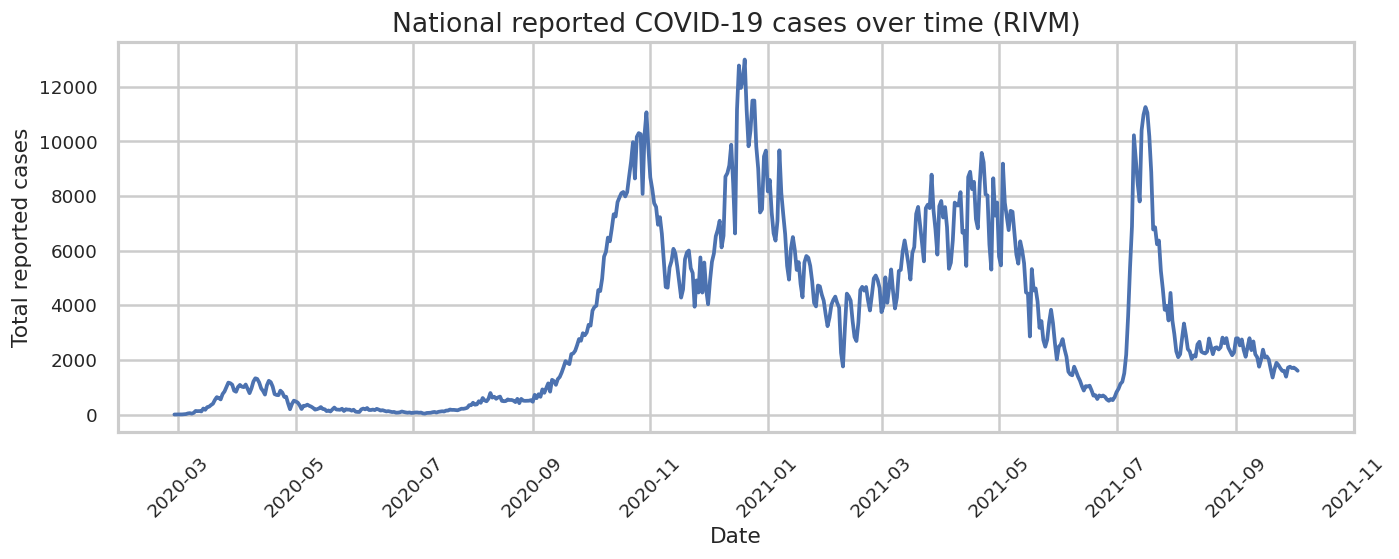

In [60]:
# Aggregate national reported cases over time (RIVM)
national_series = rivm_df.groupby(date_col)[cases_col].sum().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(national_series.index, national_series.values)
plt.title("National reported COVID-19 cases over time (RIVM)")
plt.xlabel("Date")
plt.ylabel("Total reported cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

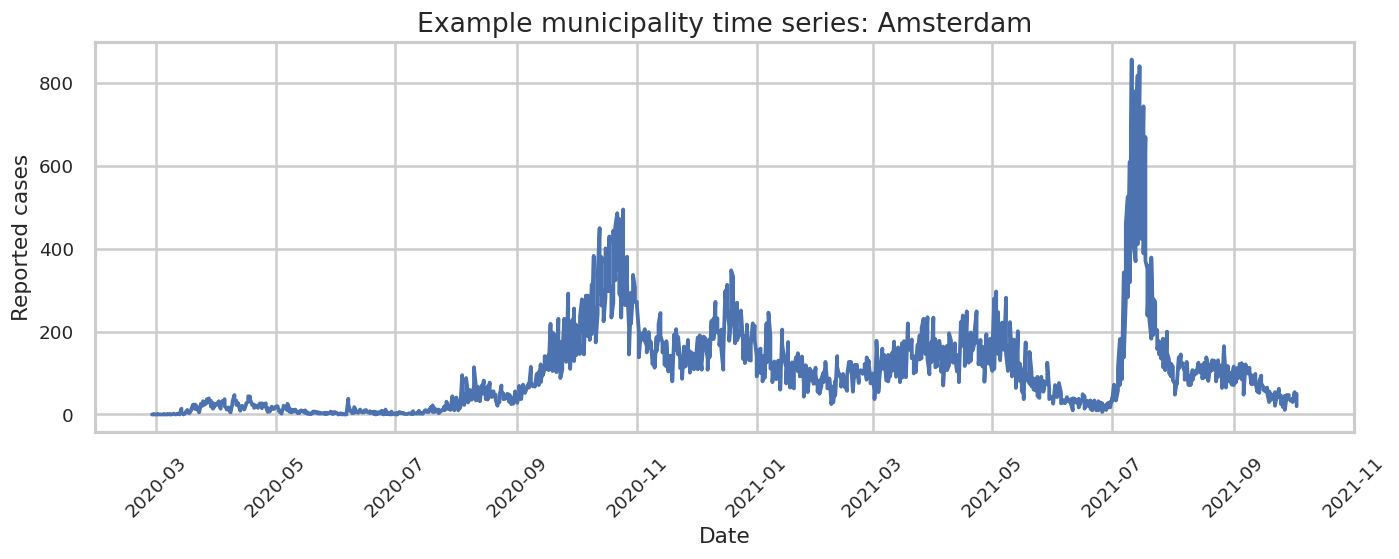

In [61]:
# Choose a municipality with high analytical relevance:
# the municipality with the highest total reported cases
top_muni = (
    rivm_df.groupby(municipality_col)[cases_col]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

example_series = (
    rivm_df[rivm_df[municipality_col] == top_muni]
    .sort_values(date_col)
)

plt.figure(figsize=(12, 5))
plt.plot(example_series[date_col], example_series[cases_col])
plt.title(f"Example municipality time series: {top_muni}")
plt.xlabel("Date")
plt.ylabel("Reported cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

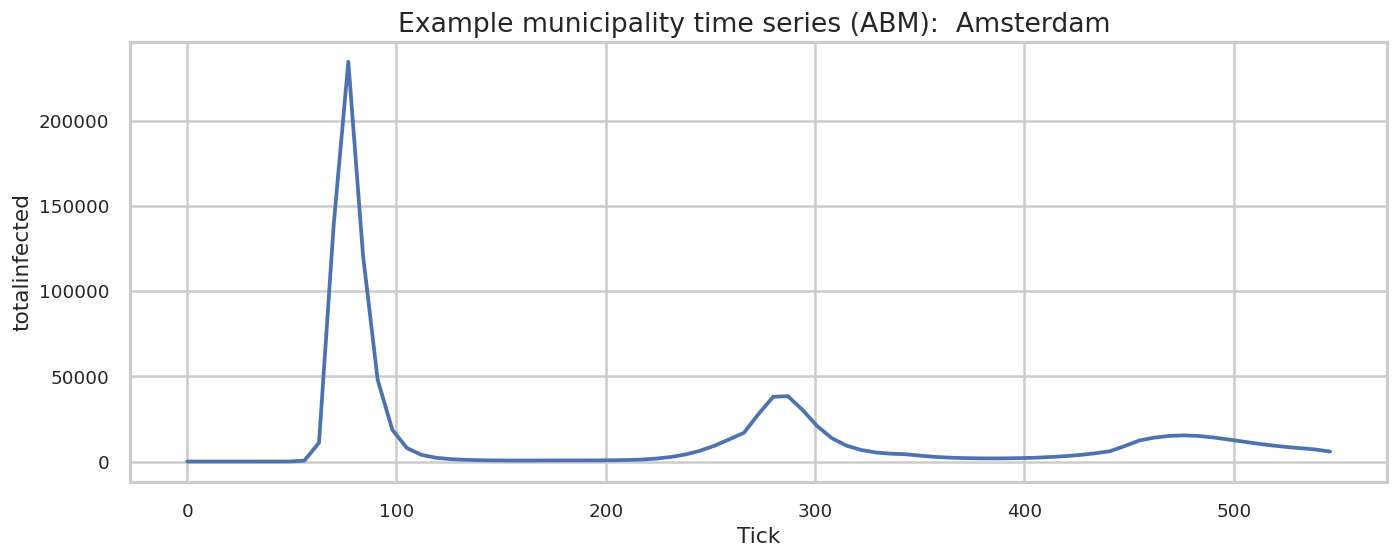

In [62]:
# Example municipality time series (ABM), if an infected column is available
possible_abm_cases = [col for col in abm_df.columns if "infect" in col.lower()]

if "name" in abm_df.columns and "ticks" in abm_df.columns and len(possible_abm_cases) > 0:
    abm_cases_col = possible_abm_cases[0]

    # Choose municipality with highest cumulative infected values
    top_abm_muni = (
        abm_df.groupby("name")[abm_cases_col]
        .sum()
        .sort_values(ascending=False)
        .index[0]
    )

    example_abm_series = (
        abm_df[abm_df["name"] == top_abm_muni]
        .sort_values("ticks")
    )

    plt.figure(figsize=(12, 5))
    plt.plot(example_abm_series["ticks"], example_abm_series[abm_cases_col])
    plt.title(f"Example municipality time series (ABM): {top_abm_muni}")
    plt.xlabel("Tick")
    plt.ylabel(abm_cases_col)
    plt.tight_layout()
    plt.show()

### Section 2 conclusion

The initial inspection shows that the RIVM dataset is stored in a long tabular format with daily municipality-level observations, whereas the ABM output is organised as municipality-level simulation records indexed by model ticks. The two datasets differ in municipality coverage, naming conventions, and temporal resolution, with the ABM reporting infection values at coarser time intervals. These differences confirm that careful restructuring, temporal alignment, and municipality-name standardisation are necessary before meaningful clustering and comparison can be performed.

## Section 3 — Data architecture and restructuring

This section converts the raw tabular datasets into a form suitable for time-series analysis and clustering.

The two raw inputs have different structures:

- The **RIVM dataset** is stored in long format, with one row per municipality-date combination.
- The **ABM output** is stored as municipality-level simulation records indexed by model ticks.

To make the datasets comparable, both are transformed into a **municipality × time matrix**, where:

- each **row** represents a municipality
- each **column** represents a time step
- each **cell** contains the reported or simulated infection value for that municipality and time

This restructuring is necessary because clustering methods such as K-Shape and SOM expect a consistent matrix-like time-series representation.

According to the model instructions, the ABM output reports infected cases at **7-day intervals** and uses ticks rather than calendar dates. Therefore, temporal alignment between the two datasets is also required before meaningful comparison can be performed.

### 3.1 Reshape RIVM data to municipality × time matrix

The RIVM data is initially stored in long format and must be pivoted into a municipality × time matrix. Before pivoting, rows with missing municipality identifiers are excluded because they cannot be assigned reliably to a municipality-specific time series.

In [63]:
# Keep only rows with valid municipality and date information
rivm_clean = rivm_df.dropna(subset=[municipality_col, municipality_code_col, date_col]).copy()

# Aggregate in case multiple rows exist for the same municipality-date combination
rivm_agg = (
    rivm_clean
    .groupby([municipality_code_col, municipality_col, date_col], as_index=False)[cases_col]
    .sum()
)

print("RIVM cleaned long-format shape:", rivm_agg.shape)
display(rivm_agg.head())

RIVM cleaned long-format shape: (200896, 4)


,Municipality_code,Municipality_name,Date_of_publication,Total_reported
0,GM0014,Groningen,2020-02-28,0
1,GM0014,Groningen,2020-02-29,0
2,GM0014,Groningen,2020-03-01,0
3,GM0014,Groningen,2020-03-02,0
4,GM0014,Groningen,2020-03-03,0


In [64]:
# Pivot to municipality × time matrix
rivm_matrix = rivm_agg.pivot_table(
    index=[municipality_code_col, municipality_col],
    columns=date_col,
    values=cases_col,
    aggfunc="sum",
    fill_value=0
)

# Sort columns chronologically
rivm_matrix = rivm_matrix.sort_index(axis=1)

print("RIVM matrix shape (municipalities × time):", rivm_matrix.shape)
display(rivm_matrix.head())

RIVM matrix shape (municipalities × time): (344, 584)


,Date_of_publication,2020-02-28,2020-02-29,2020-03-01,2020-03-02,2020-03-03,2020-03-04,2020-03-05,2020-03-06,2020-03-07,2020-03-08,...,2021-09-24,2021-09-25,2021-09-26,2021-09-27,2021-09-28,2021-09-29,2021-09-30,2021-10-01,2021-10-02,2021-10-03
Municipality_code,Municipality_name,,,,,,,,,,,,,,,,,,,,,
GM0014,Groningen,0,0,0,0,0,0,0,0,0,0,...,11,12,21,9,19,11,16,22,22,19
GM0034,Almere,0,0,0,0,0,0,1,0,0,0,...,20,26,20,8,26,23,25,26,24,34
GM0037,Stadskanaal,0,0,0,0,0,0,0,0,0,0,...,5,9,2,3,1,1,4,3,4,2
GM0047,Veendam,0,0,0,0,0,0,0,0,0,0,...,1,0,2,1,0,0,4,1,2,1
GM0050,Zeewolde,0,0,0,0,0,0,1,0,0,0,...,1,1,2,0,1,2,0,1,0,1


The resulting RIVM matrix has municipalities as rows and publication dates as columns. This creates a daily municipality-level time-series representation suitable for later preprocessing and clustering.

### 3.2 Reshape ABM output to municipality × time matrix

The ABM simulation output is already structured around municipality-level records, but it is indexed by model ticks rather than calendar dates. The output must therefore be cleaned and pivoted into the same municipality × time structure used for the RIVM data.

In [65]:
# Identify likely ABM infection column
possible_abm_cases = [col for col in abm_df.columns if "infect" in col.lower()]
print("Possible ABM infection columns:", possible_abm_cases)

Possible ABM infection columns: ['totalinfected']


In [66]:
# Set core ABM columns
abm_municipality_col = "name"
abm_municipality_clean_col = "name_clean"
abm_time_col = "ticks"
abm_x_col = "xcor" if "xcor" in abm_df.columns else None
abm_y_col = "ycor" if "ycor" in abm_df.columns else None
abm_cases_col = possible_abm_cases[0]  # adjust if needed after inspection

# Keep only rows with valid identifiers and time
abm_clean = abm_df.dropna(subset=[abm_municipality_col, abm_time_col]).copy()

# Convert numeric columns where possible
abm_clean[abm_time_col] = pd.to_numeric(abm_clean[abm_time_col], errors="coerce")
abm_clean[abm_cases_col] = pd.to_numeric(abm_clean[abm_cases_col], errors="coerce")

if abm_x_col:
    abm_clean[abm_x_col] = pd.to_numeric(abm_clean[abm_x_col], errors="coerce")
if abm_y_col:
    abm_clean[abm_y_col] = pd.to_numeric(abm_clean[abm_y_col], errors="coerce")

abm_clean = abm_clean.dropna(subset=[abm_time_col, abm_cases_col])

print("ABM cleaned long-format shape:", abm_clean.shape)
display(abm_clean.head())

ABM cleaned long-format shape: (31284, 10)


,ticks,name,xcor,ycor,totalpopulation,totalsusceptible,totalexposed,totalinfected,totalrecovered,name_clean
0,0,Wassenaar,-6.480864,-2.417199,25653.42,25653.42,0.0,0.0,0.0,Wassenaar
1,0,Molenwaard,-2.967947,-4.704459,29187.10,29187.10,0.0,0.0,0.0,Molenwaard
2,0,Hof0van0Twente,8.845898,1.653454,35211.48,35211.48,0.0,0.0,0.0,Hof van Twente
3,0,Loppersum,7.180253,14.423434,10290.95,10290.95,0.0,0.0,0.0,Loppersum
4,0,Venlo,7.743379,-8.595810,100148.99,100148.99,0.0,0.0,0.0,Venlo


In [67]:
# Aggregate in case multiple rows exist for the same municipality-tick combination
abm_agg = (
    abm_clean
    .groupby([abm_municipality_col, abm_municipality_clean_col, abm_time_col], as_index=False)[abm_cases_col]
    .sum()
)

print("ABM aggregated long-format shape:", abm_agg.shape)
display(abm_agg.head())

ABM aggregated long-format shape: (31284, 4)


,name,name_clean,ticks,totalinfected
0,Aa0en0Hunze,Aa en Hunze,0,0.0
1,Aa0en0Hunze,Aa en Hunze,7,0.0
2,Aa0en0Hunze,Aa en Hunze,14,0.0
3,Aa0en0Hunze,Aa en Hunze,21,0.0
4,Aa0en0Hunze,Aa en Hunze,28,0.0


In [68]:
# Pivot to municipality × tick matrix
abm_matrix = abm_agg.pivot_table(
    index=[abm_municipality_col, abm_municipality_clean_col],
    columns=abm_time_col,
    values=abm_cases_col,
    aggfunc="sum",
    fill_value=0
)

# Sort ticks
abm_matrix = abm_matrix.sort_index(axis=1)

print("ABM matrix shape (municipalities × ticks):", abm_matrix.shape)
display(abm_matrix.head())

ABM matrix shape (municipalities × ticks): (396, 79)


,ticks,0,7,14,21,28,35,42,49,56,63,...,483,490,497,504,511,518,525,532,539,546
name,name_clean,,,,,,,,,,,,,,,,,,,,,
Aa0en0Hunze,Aa en Hunze,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000112,5.587135e-05,2.778657e-05,1.385927e-05,6.920685e-06,3.466138e-06,1.737978e-06,8.721019e-07,4.350827e-07,2.057722e-07
Aalburg,Aalburg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000001,4.303950e-07,1.793281e-07,7.485375e-08,3.127280e-08,1.307315e-08,5.460116e-09,2.280452e-09,9.493454e-10,3.821797e-10
Aalsmeer,Aalsmeer,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,212.361537,...,115.677989,1.299557e+02,1.163505e+02,8.706047e+01,7.711389e+01,8.949543e+01,7.951293e+01,9.071556e+01,8.803047e+01,5.838514e+01
Aalten,Aalten,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Achtkarspelen,Achtkarspelen,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000215,1.107447e-04,5.723549e-05,2.960370e-05,1.532182e-05,7.934682e-06,4.111309e-06,2.136826e-06,1.103940e-06,5.385268e-07


The resulting ABM matrix has municipalities as rows and model ticks as columns. This is structurally similar to the RIVM matrix, but the time dimension still differs because the ABM uses ticks rather than daily publication dates.

### 3.3 Align time units and temporal granularity

The RIVM matrix uses daily dates, whereas the ABM matrix uses model ticks. According to the model instructions, the ABM output reports infected cases every 7 days rather than every day. Therefore, the RIVM data must be resampled to a comparable weekly temporal unit before the two datasets can be meaningfully compared.

In [69]:
# Resample RIVM daily data to weekly values by summing reported cases within each week
rivm_weekly = (
    rivm_agg
    .groupby([municipality_code_col, municipality_col, pd.Grouper(key=date_col, freq="W-MON")])[cases_col]
    .sum()
    .reset_index()
)

print("RIVM weekly long-format shape:", rivm_weekly.shape)
display(rivm_weekly.head())

RIVM weekly long-format shape: (28896, 4)


,Municipality_code,Municipality_name,Date_of_publication,Total_reported
0,GM0014,Groningen,2020-03-02,0
1,GM0014,Groningen,2020-03-09,0
2,GM0014,Groningen,2020-03-16,8
3,GM0014,Groningen,2020-03-23,46
4,GM0014,Groningen,2020-03-30,34


In [70]:
# Pivot weekly RIVM data to municipality × week matrix
rivm_weekly_matrix = rivm_weekly.pivot_table(
    index=[municipality_code_col, municipality_col],
    columns=date_col,
    values=cases_col,
    aggfunc="sum",
    fill_value=0
)

rivm_weekly_matrix = rivm_weekly_matrix.sort_index(axis=1)

print("RIVM weekly matrix shape:", rivm_weekly_matrix.shape)
display(rivm_weekly_matrix.head())

RIVM weekly matrix shape: (344, 84)


,Date_of_publication,2020-03-02,2020-03-09,2020-03-16,2020-03-23,2020-03-30,2020-04-06,2020-04-13,2020-04-20,2020-04-27,2020-05-04,...,2021-08-02,2021-08-09,2021-08-16,2021-08-23,2021-08-30,2021-09-06,2021-09-13,2021-09-20,2021-09-27,2021-10-04
Municipality_code,Municipality_name,,,,,,,,,,,,,,,,,,,,,
GM0014,Groningen,0,0,8,46,34,21,28,12,7,4,...,280,208,214,226,257,236,208,150,102,109
GM0034,Almere,0,1,2,16,42,61,46,69,62,39,...,398,376,367,507,340,309,307,216,142,158
GM0037,Stadskanaal,0,0,0,0,1,0,3,0,1,0,...,20,20,15,21,10,21,27,10,28,15
GM0047,Veendam,0,0,0,0,2,3,1,1,1,0,...,21,16,9,29,19,11,26,25,7,8
GM0050,Zeewolde,0,1,1,2,4,7,5,6,8,3,...,32,14,29,23,29,17,21,9,10,5


In [71]:
# Inspect weekly time dimension compared with ABM ticks
print("Number of weekly time steps in RIVM:", rivm_weekly_matrix.shape[1])
print("Number of tick-based time steps in ABM:", abm_matrix.shape[1])

print("\nFirst 10 RIVM weekly columns:")
display(pd.Index(rivm_weekly_matrix.columns[:10], name="RIVM_weekly_dates"))

print("\nFirst 10 ABM tick columns:")
display(pd.Index(abm_matrix.columns[:10], name="ABM_ticks"))

Number of weekly time steps in RIVM: 84
Number of tick-based time steps in ABM: 79

First 10 RIVM weekly columns:


DatetimeIndex(['2020-03-02', '2020-03-09', '2020-03-16', '2020-03-23',
               '2020-03-30', '2020-04-06', '2020-04-13', '2020-04-20',
               '2020-04-27', '2020-05-04'],
              dtype='datetime64[us]', name='RIVM_weekly_dates', freq=None)


First 10 ABM tick columns:


Index([0, 7, 14, 21, 28, 35, 42, 49, 56, 63], dtype='int64', name='ABM_ticks')

The weekly aggregation brings the RIVM data closer to the temporal resolution of the ABM output. The two time axes are still not identical in meaning, but both now represent coarser epidemic evolution steps rather than daily counts, making later comparison more defensible.

### 3.4 Align municipality identifiers

The municipality identifiers in the two datasets are not directly comparable. The RIVM data uses municipality codes and official municipality names, whereas the ABM output uses municipality names with formatting artefacts such as embedded zeros.

For this reason, a preliminary name standardisation step is introduced. Exact cross-dataset harmonisation may still require further cleaning, but this step makes the mismatch explicit and prepares the data for later comparison.

In [72]:
# Prepare comparable municipality-name lists
rivm_names = pd.Series(
    rivm_agg[municipality_col].dropna().unique(),
    name="rivm_name"
).sort_values().reset_index(drop=True)

abm_names = pd.Series(
    abm_agg[abm_municipality_clean_col].dropna().unique(),
    name="abm_name_clean"
).sort_values().reset_index(drop=True)

print("Number of unique RIVM municipality names:", len(rivm_names))
print("Number of unique cleaned ABM municipality names:", len(abm_names))

Number of unique RIVM municipality names: 344
Number of unique cleaned ABM municipality names: 396


In [73]:
# Quick overlap check
common_names = sorted(set(rivm_names).intersection(set(abm_names)))
rivm_only = sorted(set(rivm_names) - set(abm_names))
abm_only = sorted(set(abm_names) - set(rivm_names))

print("Number of common municipality names:", len(common_names))
print("Number of RIVM-only names:", len(rivm_only))
print("Number of ABM-only names:", len(abm_only))

print("\nExample common names:")
display(pd.Series(common_names[:20], name="common_names"))

print("\nExample RIVM-only names:")
display(pd.Series(rivm_only[:20], name="rivm_only_names"))

print("\nExample ABM-only names:")
display(pd.Series(abm_only[:20], name="abm_only_names"))

Number of common municipality names: 269
Number of RIVM-only names: 75
Number of ABM-only names: 127

Example common names:


0             Aa en Hunze
1                Aalsmeer
2                  Aalten
3           Achtkarspelen
4            Alblasserdam
5           Albrandswaard
6                 Alkmaar
7                  Almelo
8                  Almere
9     Alphen aan den Rijn
10             Amersfoort
11             Amstelveen
12              Amsterdam
13              Apeldoorn
14                 Arnhem
15                  Assen
16                  Asten
17                  Baarn
18            Barendrecht
19              Barneveld
Name: common_names, dtype: str


Example RIVM-only names:


0           's-Gravenhage
1        's-Hertogenbosch
2            Alphen-Chaam
3                  Altena
4                 Ameland
5           Baarle-Nassau
6                    Beek
7              Beekdaelen
8             Berg en Dal
9             Bergen (L.)
10           Bergen (NH.)
11    Bodegraven-Reeuwijk
12          Borger-Odoorn
13       De Fryske Marren
14          Dijk en Waard
15          Echt-Susteren
16          Edam-Volendam
17              Eemsdelta
18      Eijsden-Margraten
19             Etten-Leur
Name: rivm_only_names, dtype: str


Example ABM-only names:


0                 Aalburg
1            Alphen Chaam
2              Appingedam
3                   Bedum
4                  Beek L
5                Beemster
6            Bellingwedde
7             Bergambacht
8                Bergen L
9               Bergen NH
10               Bernisse
11             Binnenmaas
12           Boarnsterhim
13    Bodegraven Reeuwijk
14          Borger Odoorn
15                Boskoop
16                Boxmeer
17                 Bussum
18            Cromstrijen
19                  Cuijk
Name: abm_only_names, dtype: str

This overlap check confirms that municipality identifiers are only partially aligned in their raw form. The mismatch is expected because of naming artefacts, municipality reorganisations, and differences between administrative definitions used by the two sources. Exact harmonisation will be refined later if a direct municipality-by-municipality comparison is required.

### Section 3 outputs summary

At the end of this section, the following matrix-form datasets are available for later preprocessing and clustering:

- `rivm_matrix`: municipality × daily date matrix
- `rivm_weekly_matrix`: municipality × weekly date matrix
- `abm_matrix`: municipality × tick matrix

These matrices form the core analytical inputs for the subsequent preprocessing and segmentation stages.

In [74]:
print("Final matrix shapes:")
print("RIVM daily matrix:", rivm_matrix.shape)
print("RIVM weekly matrix:", rivm_weekly_matrix.shape)
print("ABM matrix:", abm_matrix.shape)

Final matrix shapes:
RIVM daily matrix: (344, 584)
RIVM weekly matrix: (344, 84)
ABM matrix: (396, 79)


In [75]:
print("Example rows from RIVM weekly matrix:")
display(rivm_weekly_matrix.head())

print("Example rows from ABM matrix:")
display(abm_matrix.head())

Example rows from RIVM weekly matrix:


,Date_of_publication,2020-03-02,2020-03-09,2020-03-16,2020-03-23,2020-03-30,2020-04-06,2020-04-13,2020-04-20,2020-04-27,2020-05-04,...,2021-08-02,2021-08-09,2021-08-16,2021-08-23,2021-08-30,2021-09-06,2021-09-13,2021-09-20,2021-09-27,2021-10-04
Municipality_code,Municipality_name,,,,,,,,,,,,,,,,,,,,,
GM0014,Groningen,0,0,8,46,34,21,28,12,7,4,...,280,208,214,226,257,236,208,150,102,109
GM0034,Almere,0,1,2,16,42,61,46,69,62,39,...,398,376,367,507,340,309,307,216,142,158
GM0037,Stadskanaal,0,0,0,0,1,0,3,0,1,0,...,20,20,15,21,10,21,27,10,28,15
GM0047,Veendam,0,0,0,0,2,3,1,1,1,0,...,21,16,9,29,19,11,26,25,7,8
GM0050,Zeewolde,0,1,1,2,4,7,5,6,8,3,...,32,14,29,23,29,17,21,9,10,5


Example rows from ABM matrix:


,ticks,0,7,14,21,28,35,42,49,56,63,...,483,490,497,504,511,518,525,532,539,546
name,name_clean,,,,,,,,,,,,,,,,,,,,,
Aa0en0Hunze,Aa en Hunze,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000112,5.587135e-05,2.778657e-05,1.385927e-05,6.920685e-06,3.466138e-06,1.737978e-06,8.721019e-07,4.350827e-07,2.057722e-07
Aalburg,Aalburg,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000001,4.303950e-07,1.793281e-07,7.485375e-08,3.127280e-08,1.307315e-08,5.460116e-09,2.280452e-09,9.493454e-10,3.821797e-10
Aalsmeer,Aalsmeer,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,212.361537,...,115.677989,1.299557e+02,1.163505e+02,8.706047e+01,7.711389e+01,8.949543e+01,7.951293e+01,9.071556e+01,8.803047e+01,5.838514e+01
Aalten,Aalten,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Achtkarspelen,Achtkarspelen,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000215,1.107447e-04,5.723549e-05,2.960370e-05,1.532182e-05,7.934682e-06,4.111309e-06,2.136826e-06,1.103940e-06,5.385268e-07


In [79]:
# Select the dataset that will be used for clustering
# (weekly RIVM data is used because it aligns best with ABM tick resolution)

clustering_data_rivm = rivm_weekly_matrix.copy()
clustering_data_abm = abm_matrix.copy()

print("Clustering dataset shapes:")
print("RIVM:", clustering_data_rivm.shape)
print("ABM:", clustering_data_abm.shape)

Clustering dataset shapes:
RIVM: (344, 84)
ABM: (396, 79)


For clustering analysis, the weekly RIVM matrix and the ABM matrix are used as the primary datasets. 
These matrices provide comparable municipality-level epidemic time series that can be used as inputs 
for time-series clustering algorithms such as K-Shape or Self-Organising Maps.

### Quick heatmaps of raw values

To obtain an initial impression of the raw municipality-level temporal structure, quick heatmaps are shown below. These are exploratory views only; the values have not yet been smoothed or normalised.

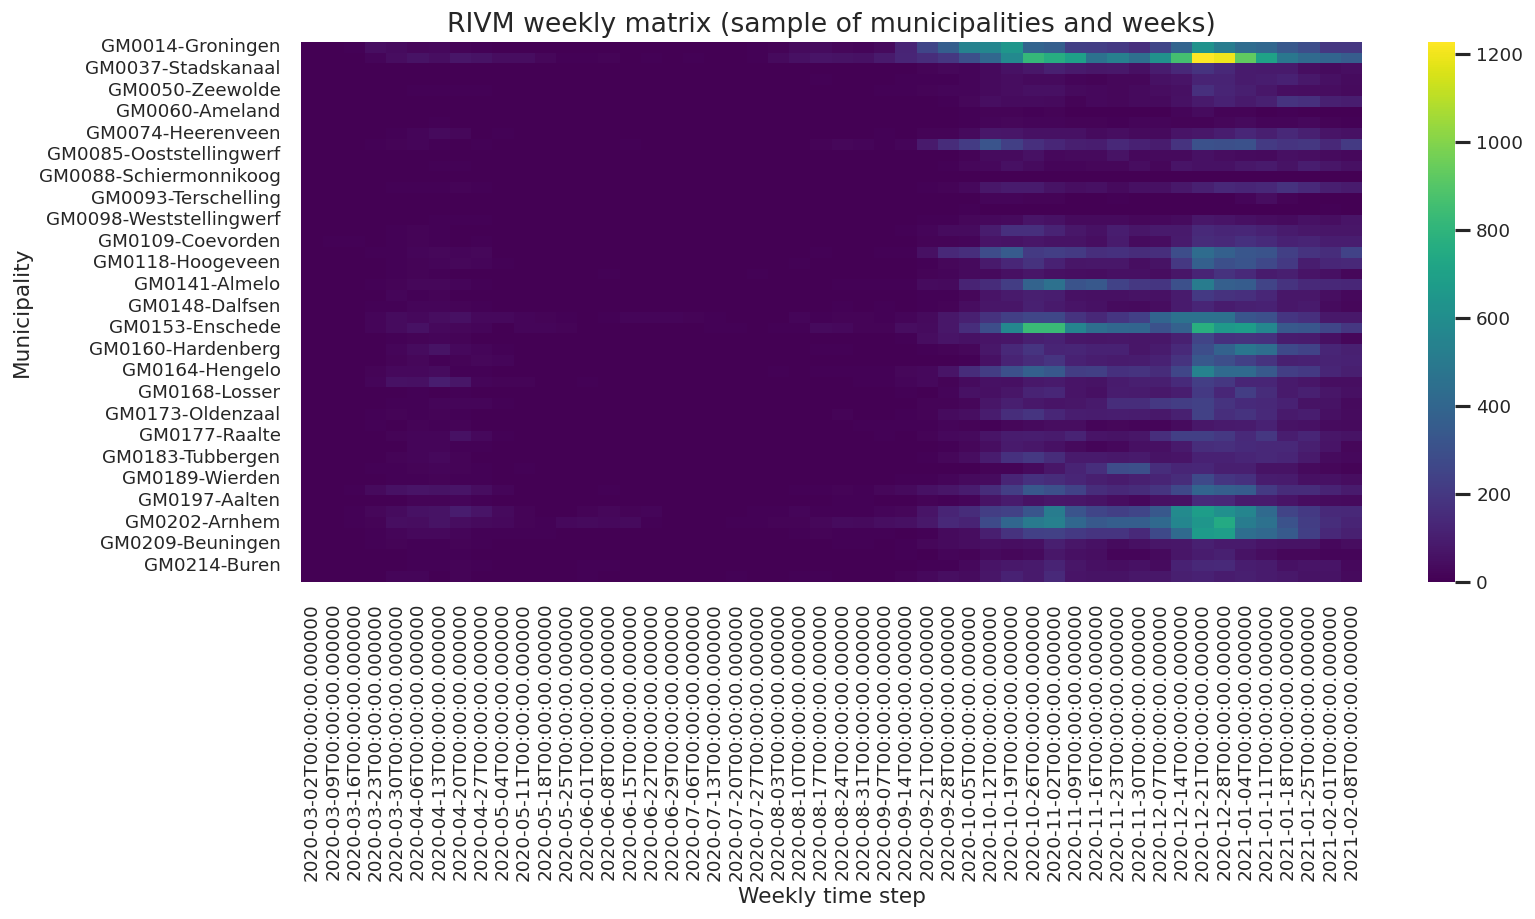

In [78]:
# Quick heatmap for a subset of municipalities to keep the plot readable
rivm_heatmap_sample = rivm_weekly_matrix.iloc[:50, :50]

plt.figure(figsize=(14, 8))
sns.heatmap(rivm_heatmap_sample, cmap="viridis")
plt.title("RIVM weekly matrix (sample of municipalities and weeks)")
plt.xlabel("Weekly time step")
plt.ylabel("Municipality")
plt.tight_layout()
plt.show()

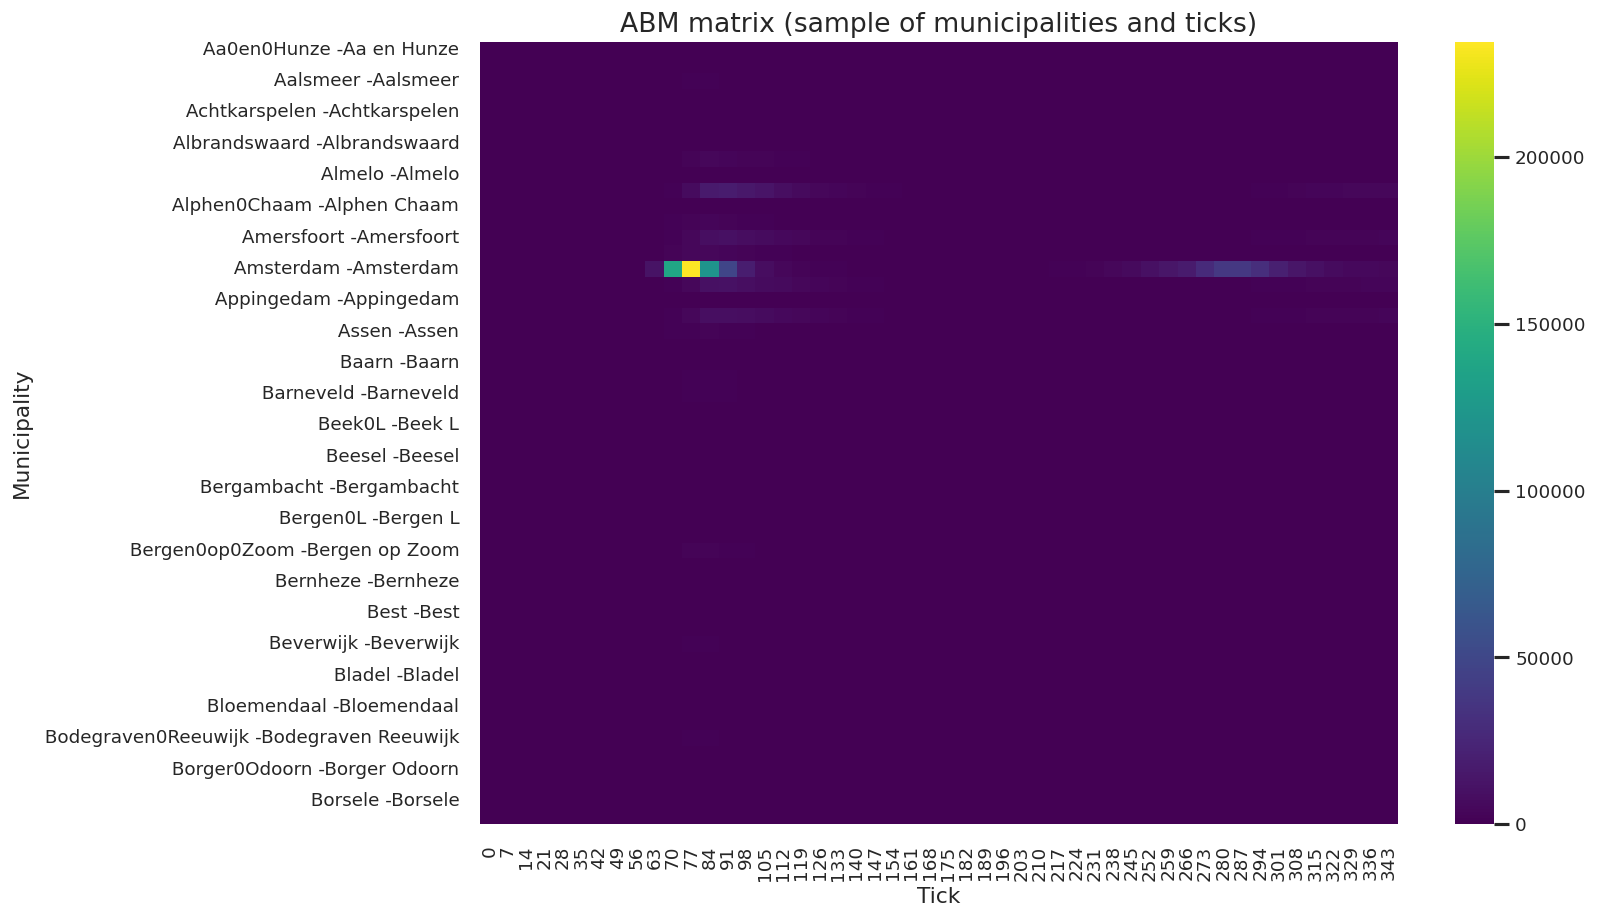

In [77]:
abm_heatmap_sample = abm_matrix.iloc[:50, :50]

plt.figure(figsize=(14, 8))
sns.heatmap(abm_heatmap_sample, cmap="viridis")
plt.title("ABM matrix (sample of municipalities and ticks)")
plt.xlabel("Tick")
plt.ylabel("Municipality")
plt.tight_layout()
plt.show()

### Section 3 conclusion

The raw RIVM and ABM datasets have now been restructured into matrix-based time-series representations suitable for later preprocessing and clustering. The RIVM data required pivoting from long format and weekly aggregation to better match the coarser temporal resolution of the ABM output. The ABM output required parsing and municipality-name cleaning before matrix construction. Although the two sources are now structurally more comparable, further preprocessing is still necessary to address differences in scale, noise, and temporal interpretation.

## Section 4 — Preprocessing choices

Before applying clustering algorithms, the time-series data must be preprocessed to reduce noise and ensure comparability between municipalities.

Epidemic time-series data often contains reporting noise and large differences in magnitude between municipalities. Without preprocessing, clustering algorithms may group municipalities based on total case counts rather than the temporal shape of epidemic dynamics.

This section evaluates several preprocessing strategies:

1. **Smoothing** to reduce short-term reporting noise.
2. **Normalisation / transformation** to control differences in magnitude.
3. **Temporal alignment** between observed and simulated data.
4. **Visual comparison of preprocessing effects** on example municipalities.

These steps ensure that the clustering analysis focuses on meaningful epidemic patterns rather than artefacts of the reporting process.

### 4.1 Smoothing

Weekly epidemic counts can contain short-term fluctuations caused by reporting delays, testing patterns, or administrative corrections. These fluctuations introduce noise that may distort clustering results.

To reduce this noise, a **rolling mean smoothing** approach is applied. This method replaces each value with the average of neighbouring observations, producing a smoother epidemic curve while preserving the overall trend.

Two versions of the data are considered:

- **Raw time series**
- **Smoothed time series using a rolling mean**

Comparing these versions helps assess whether smoothing improves the stability of the epidemic patterns used for clustering.

In [81]:
# Rolling mean smoothing for RIVM weekly data
rivm_smoothed = (
    rivm_weekly_matrix.T
    .rolling(window=3, center=True, min_periods=1)
    .mean()
    .T
)

# Rolling mean smoothing for ABM data
abm_smoothed = (
    abm_matrix.T
    .rolling(window=3, center=True, min_periods=1)
    .mean()
    .T
)

print("Smoothed datasets created")

Smoothed datasets created


In [86]:
print("Original RIVM matrix:", rivm_weekly_matrix.shape)
print("Smoothed RIVM matrix:", rivm_smoothed.shape)

print("Original ABM matrix:", abm_matrix.shape)
print("Smoothed ABM matrix:", abm_smoothed.shape)

Original RIVM matrix: (344, 84)
Smoothed RIVM matrix: (344, 84)
Original ABM matrix: (396, 79)
Smoothed ABM matrix: (396, 79)


### 4.2 Normalisation and transformation

Municipalities differ greatly in population size and total infection counts. If raw case counts are used directly, clustering algorithms may group municipalities primarily based on magnitude rather than epidemic dynamics.

To address this issue, two normalisation strategies are evaluated:

1. **Z-score normalisation**  
   Each municipality time series is centred and scaled using its mean and standard deviation. This emphasises the **temporal shape** of the epidemic curve.

2. **Min–max scaling**  
   Each time series is rescaled to the range [0,1]. This preserves relative patterns while removing differences in magnitude.

These choices influence the interpretation of clustering results:

- **Raw counts** emphasise epidemic magnitude.
- **Z-score normalisation** emphasises temporal dynamics.
- **Min–max scaling** highlights relative epidemic intensity over time.

In [82]:
# Z-score normalization per municipality
def zscore_normalise(df):
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1) + 1e-8, axis=0)

rivm_zscore = zscore_normalise(rivm_smoothed)
abm_zscore = zscore_normalise(abm_smoothed)

print("Z-score normalisation completed")

Z-score normalisation completed


In [83]:
# Min-max scaling per municipality
def minmax_scale(df):
    return (df.sub(df.min(axis=1), axis=0)
            .div((df.max(axis=1) - df.min(axis=1)) + 1e-8, axis=0))

rivm_minmax = minmax_scale(rivm_smoothed)
abm_minmax = minmax_scale(abm_smoothed)

print("Min-max scaling completed")

Min-max scaling completed


In [94]:
print("RIVM z-score row means (first 5):")
display(rivm_zscore.mean(axis=1).head())

print("\n\nRIVM min-max row minima/maxima (first 5):")
display(pd.DataFrame({
    "min": rivm_minmax.min(axis=1).head(),
    "max": rivm_minmax.max(axis=1).head()
}))

RIVM z-score row means (first 5):


Municipality_code  Municipality_name
GM0014             Groningen            2.154361e-16
GM0034             Almere              -6.872809e-17
GM0037             Stadskanaal         -2.048626e-17
GM0047             Veendam             -7.930164e-17
GM0050             Zeewolde             1.586033e-17
dtype: float64



RIVM min-max row minima/maxima (first 5):


,,min,max
Municipality_code,Municipality_name,,
GM0014,Groningen,0.0,1.0
GM0034,Almere,0.0,1.0
GM0037,Stadskanaal,0.0,1.0
GM0047,Veendam,0.0,1.0
GM0050,Zeewolde,0.0,1.0


### Log scaling

Epidemic case counts can be highly skewed, with large peaks during major waves. A logarithmic transformation can reduce the influence of extreme values and make temporal patterns easier to compare.

The transformation used is:

log(1 + cases)

This avoids issues with zero values while compressing large peaks.

In [84]:
# Log transform
rivm_log = np.log1p(rivm_smoothed)
abm_log = np.log1p(abm_smoothed)

### 4.3 Temporal alignment

The RIVM dataset originally contains daily observations, while the ABM simulation reports infections at discrete model ticks. According to the simulation setup, these ticks correspond approximately to weekly intervals.

To ensure comparability between observed and simulated epidemic patterns, the RIVM data was aggregated to weekly counts in Section 3. This produces time-series datasets with comparable temporal resolution.

Although the time indices still differ conceptually (calendar dates vs. simulation ticks), both datasets now represent similar epidemic evolution intervals, allowing meaningful comparison in clustering analysis.

### 4.4 Visual comparison of preprocessing effects

To illustrate how preprocessing changes the structure of the epidemic time series, an example municipality is plotted under different preprocessing strategies:

- Raw weekly counts
- Smoothed series
- Z-score normalised series
- Min–max scaled series

This comparison helps illustrate how preprocessing influences the patterns that clustering algorithms will detect.

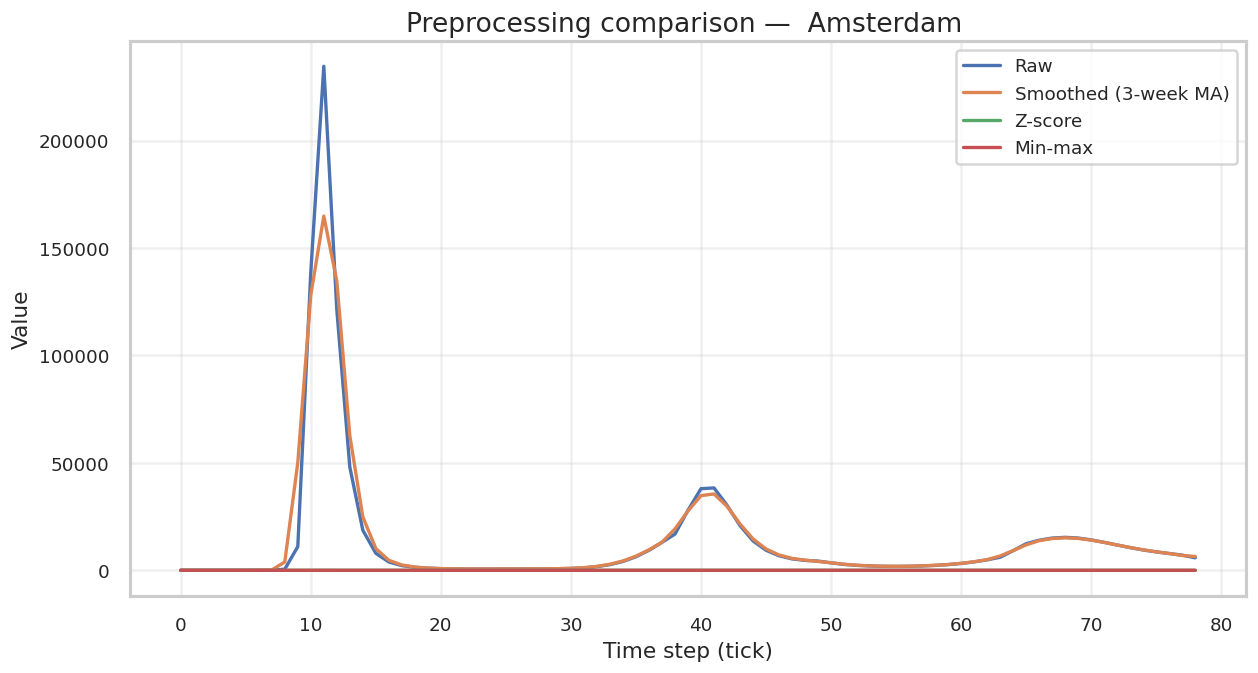

In [91]:
# Select the same municipality used earlier
example_abm_muni = top_abm_muni

# Extract a single municipality row from the MultiIndex
raw_series = abm_matrix.xs(example_abm_muni, level=0).iloc[0]
smooth_series = abm_smoothed.xs(example_abm_muni, level=0).iloc[0]
z_series = abm_zscore.xs(example_abm_muni, level=0).iloc[0]
minmax_series = abm_minmax.xs(example_abm_muni, level=0).iloc[0]

plt.figure(figsize=(12,6))

plt.plot(raw_series.values, label="Raw", linewidth=2)
plt.plot(smooth_series.values, label="Smoothed (3-week MA)", linewidth=2)
plt.plot(z_series.values, label="Z-score", linewidth=2)
plt.plot(minmax_series.values, label="Min-max", linewidth=2)

plt.grid(alpha=0.3)

plt.title(f"Preprocessing comparison — {example_abm_muni}")
plt.xlabel("Time step (tick)")
plt.ylabel("Value")

plt.legend()
plt.show()

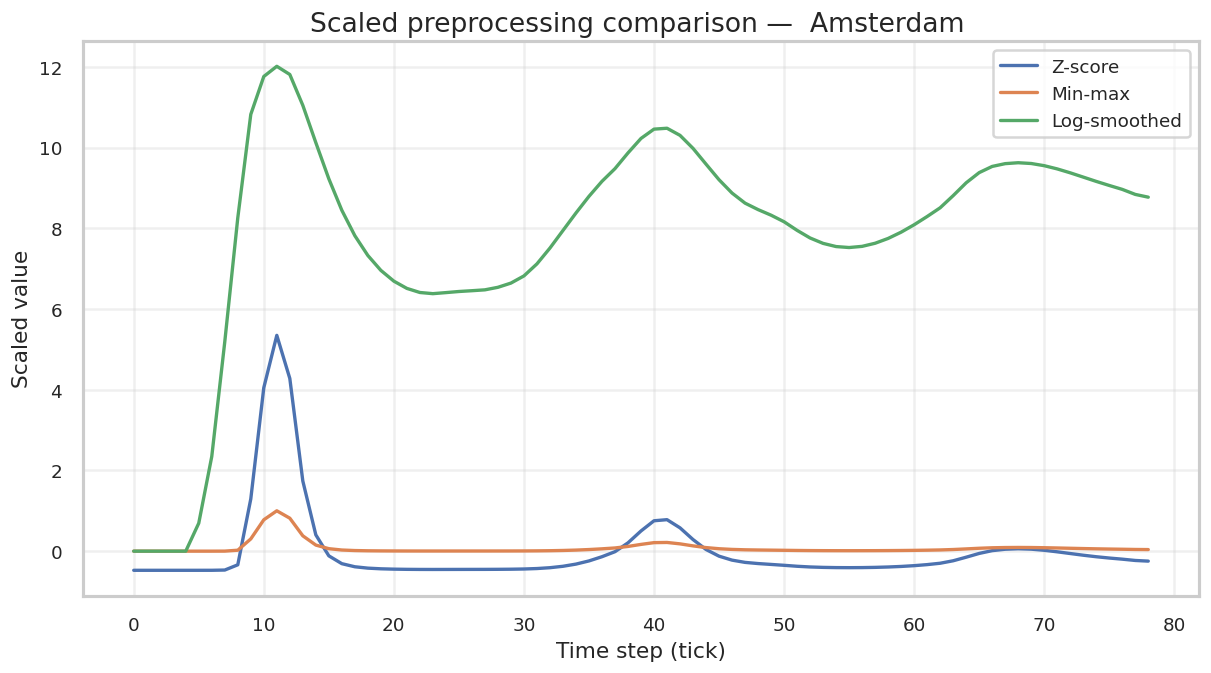

In [92]:
plt.figure(figsize=(12,6))
plt.plot(z_series.values, label="Z-score", linewidth=2)
plt.plot(minmax_series.values, label="Min-max", linewidth=2)
plt.plot(np.log1p(smooth_series.values), label="Log-smoothed", linewidth=2)

plt.grid(alpha=0.3)
plt.title(f"Scaled preprocessing comparison — {example_abm_muni}")
plt.xlabel("Time step (tick)")
plt.ylabel("Scaled value")
plt.legend()
plt.show()

### Section 4 conclusion

Several preprocessing strategies were explored to prepare the epidemic time-series data for clustering analysis.

Smoothing was applied to reduce short-term fluctuations caused by reporting artefacts, while normalisation methods were used to control differences in magnitude between municipalities. These transformations allow clustering algorithms to focus on the temporal shape of epidemic curves rather than absolute case counts.

The comparison plot demonstrates how preprocessing significantly alters the representation of epidemic dynamics. The same example municipality (Amsterdam) introduced in Section 2 is used to illustrate the effects of preprocessing. The final clustering analysis will therefore use the smoothed and normalised time series to identify municipalities with similar epidemic patterns.

For the main clustering analysis, the smoothed z-score-normalised time series will be used as the primary representation, because this preprocessing combination emphasises temporal epidemic shape while reducing the influence of short-term noise and absolute case magnitude.

## Section 5 — Time-series segmentation

Epidemic time series often contain multiple phases corresponding to different waves of infection. 
These waves reflect changes in transmission dynamics, policy interventions, behavioural responses, 
and virus variants.

Clustering the entire time series without considering these phases may hide important temporal 
differences between municipalities. For example, municipalities may experience similar dynamics 
during one wave but diverge during another.

To better analyse these patterns, the epidemic curve is segmented into major waves. 
These segments can then be analysed separately in addition to the full time series.

The segmentation process consists of:

1. Identifying wave boundaries using the national epidemic curve.
2. Defining time windows corresponding to each wave.
3. Creating segment-specific datasets for further analysis.

### 5.1 Why segment the epidemic

COVID-19 spread in multiple waves rather than a single continuous outbreak. 
Each wave represents a distinct phase of the epidemic influenced by different 
conditions such as mobility restrictions, seasonal effects, and virus variants.

Segmenting the time series allows clustering algorithms to capture municipality 
similarities within specific epidemic phases. This can reveal patterns such as:

- municipalities that peaked early in the first wave
- municipalities that experienced delayed peaks
- municipalities strongly affected during later waves

Analysing wave segments therefore provides a more detailed view of epidemic dynamics.

### 5.2 Detect epidemic waves

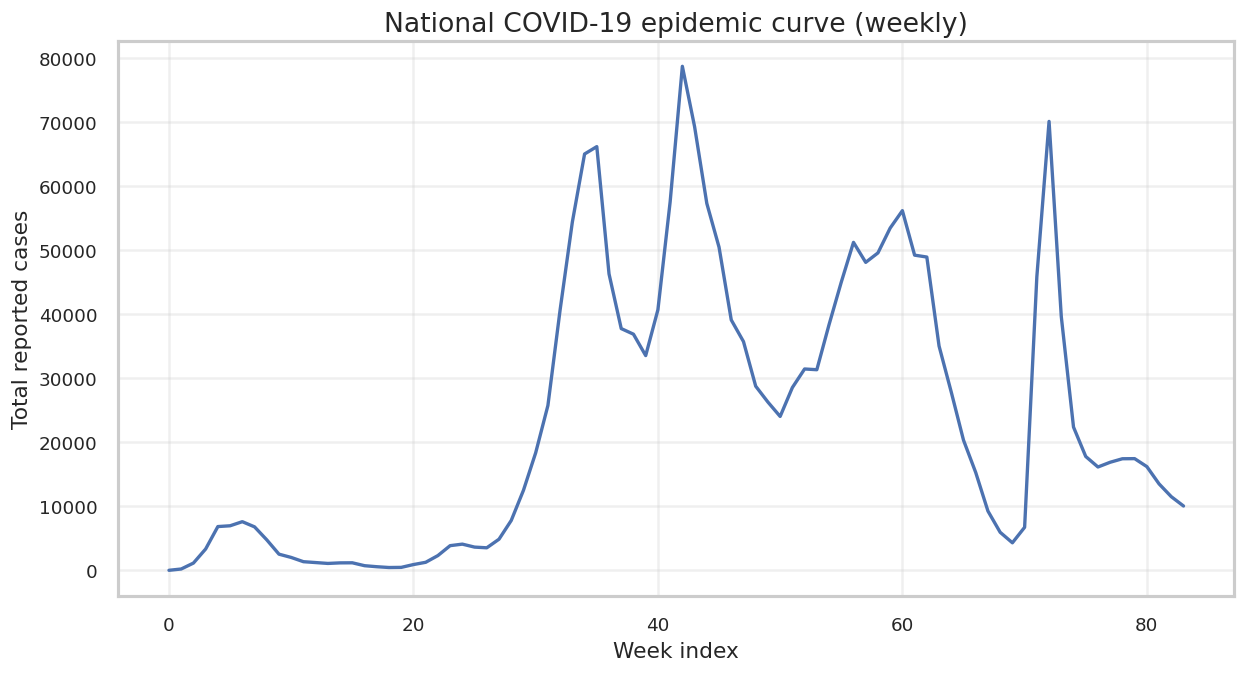

In [95]:
# Create national weekly epidemic curve
national_curve = rivm_weekly_matrix.sum(axis=0)

plt.figure(figsize=(12,6))
plt.plot(national_curve.values, linewidth=2)

plt.title("National COVID-19 epidemic curve (weekly)")
plt.xlabel("Week index")
plt.ylabel("Total reported cases")

plt.grid(alpha=0.3)
plt.show()

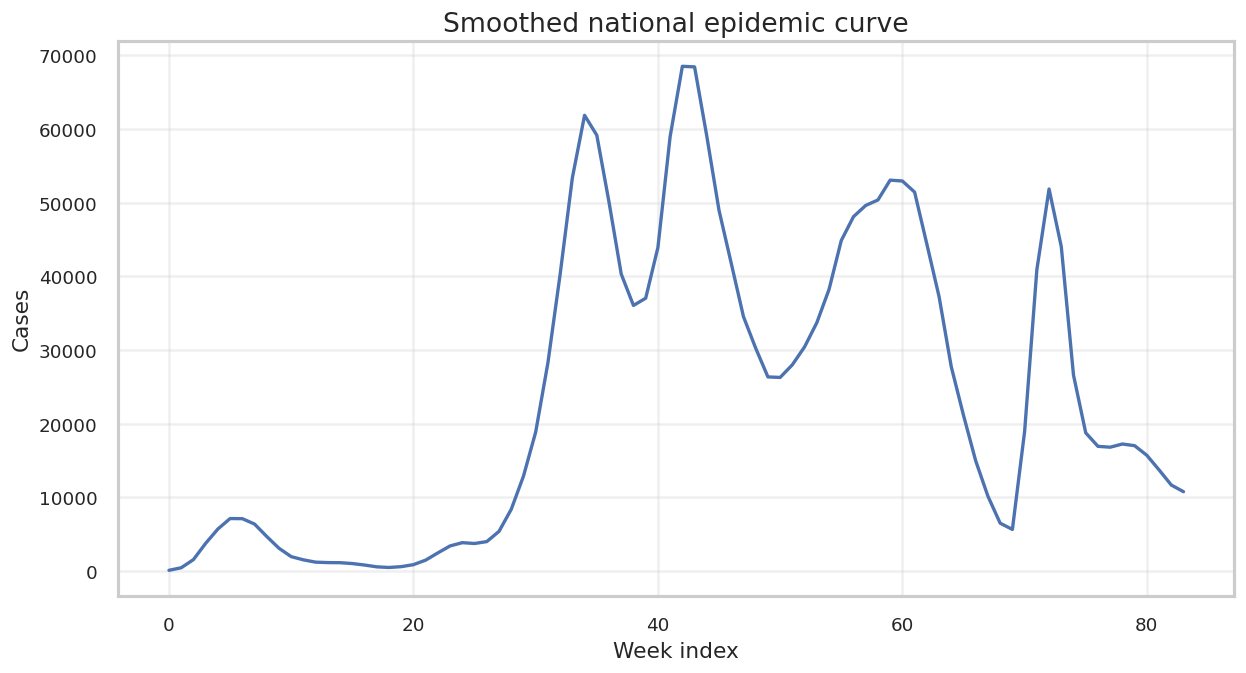

In [96]:
national_smoothed = (
    pd.Series(national_curve)
    .rolling(window=3, center=True, min_periods=1)
    .mean()
)

plt.figure(figsize=(12,6))
plt.plot(national_smoothed.values, linewidth=2)

plt.title("Smoothed national epidemic curve")
plt.xlabel("Week index")
plt.ylabel("Cases")

plt.grid(alpha=0.3)
plt.show()

### 5.3 Define wave boundaries

In [107]:
wave_boundaries = {
    "wave1": (0, 12),
    "wave2": (23, 39),
    "wave3": (40, 50),
    "wave4": (51, 66),
    "wave5": (67, 83)
}

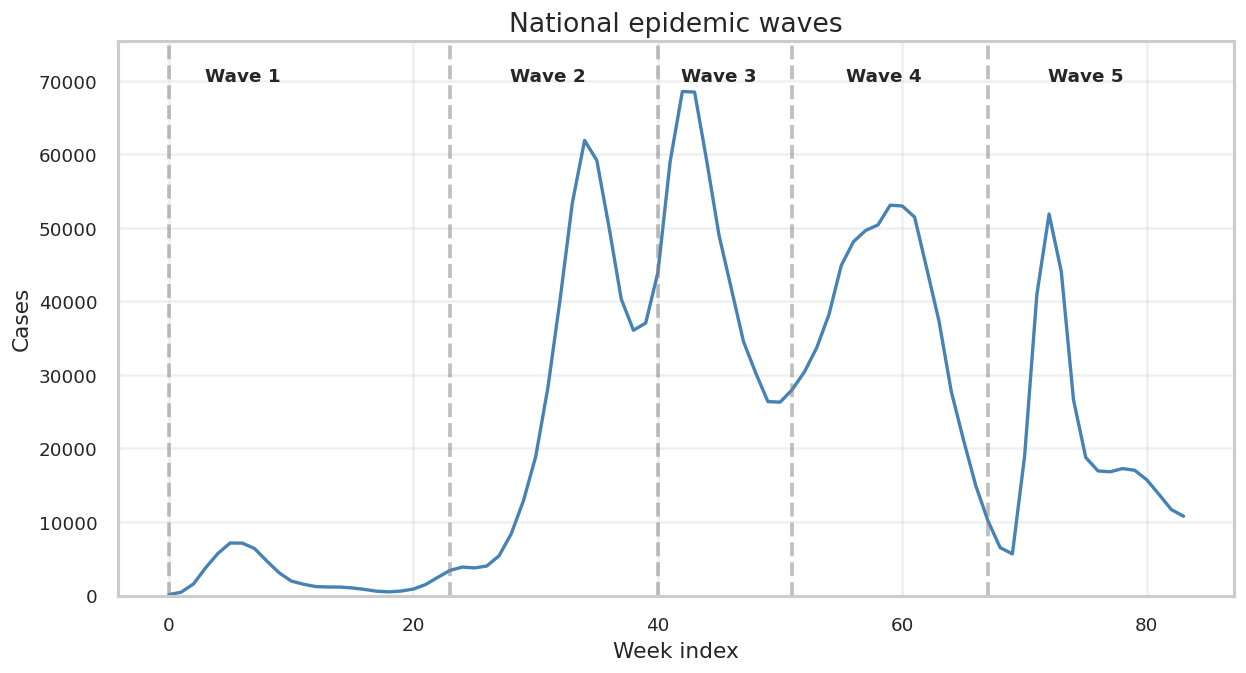

In [127]:
# Plot wave boundaries
plt.figure(figsize=(12,6))
plt.plot(national_smoothed.values, linewidth=2, color="steelblue")

y_max = national_smoothed.max()

for wave, (start, end) in wave_boundaries.items():
    
    # draw boundary line
    plt.axvline(start, linestyle="--", alpha=0.5, color="gray")
    
    # compute middle of segment
    mid = (start + end) / 2
    
    # formatted label
    label = wave.replace("wave", "Wave ")
    
    # add label above curve
    plt.text(mid, y_max*1.02,
             label,
             ha="center",
             fontsize=11,
             fontweight="bold")

plt.title("National epidemic waves")
plt.xlabel("Week index")
plt.ylabel("Cases")

plt.grid(alpha=0.3)
plt.ylim(0, y_max*1.1)

plt.show()

Although the lecture slides illustrate four broad epidemic waves, the weekly national curve derived from the RIVM data suggests an additional late sharp phase. Therefore, segmentation was defined using the observed smoothed national curve rather than forcing a fixed four-wave structure.

### 5.4 Segment datasets

The segmented datasets are derived from the z-score normalised time series, ensuring that clustering focuses on temporal pattern similarity rather than absolute case magnitude.

In [101]:
wave_datasets = {}

for wave, (start, end) in wave_boundaries.items():
    wave_datasets[wave] = rivm_zscore.iloc[:, start:end]

for wave in wave_datasets:
    print(wave, wave_datasets[wave].shape)

wave1 (344, 12)
wave2 (344, 16)
wave3 (344, 10)
wave4 (344, 15)
wave5 (344, 16)


In [116]:
start_weeks = [v[0] for v in wave_boundaries.values()]
end_weeks = [v[1] for v in wave_boundaries.values()]

segment_table = pd.DataFrame({
    "Wave": list(wave_boundaries.keys()),
    "Start_week": start_weeks,
    "End_week": end_weeks,
})

segment_table["Start_date"] = rivm_weekly_matrix.columns[start_weeks].values
segment_table["End_date"] = rivm_weekly_matrix.columns[[w - 1 for w in end_weeks]].values
segment_table["Length"] = segment_table["End_week"] - segment_table["Start_week"]

display(segment_table)

,Wave,Start_week,End_week,Start_date,End_date,Length
0,wave1,0,12,2020-03-02,2020-05-18,12
1,wave2,23,39,2020-08-10,2020-11-23,16
2,wave3,40,50,2020-12-07,2021-02-08,10
3,wave4,51,66,2021-02-22,2021-05-31,15
4,wave5,67,83,2021-06-14,2021-09-27,16


### Section 5 conclusion

The epidemic time series was segmented into major waves based on the national 
infection curve. These segments capture distinct phases of the COVID-19 outbreak.

Segment-based datasets were created to allow clustering analysis both on the 
full epidemic time series and on individual waves. This approach enables a 
more detailed exploration of municipality-level epidemic dynamics across 
different phases of the pandemic.